# Lightning Run Analysis (CLI Workflow)

Analyzes training results produced by `closure-train fit`.

`RunLoader` reconstructs the model, data, and test dataset from a
Lightning `version_*` directory, and provides one-liner access to
training history, evaluation metrics, and visualization.

## 1) CLI commands (for reference)

```bash
closure-train fit  --config configs/legacy_harris_4lrs_es500.yaml --trainer.devices=1 --trainer.strategy=auto    --data.num_workers=2    --trainer.logger.init_args.name=CNN --trainer.logger.init_args.version=run_2 --model.network.init_args.channels='[10,256,128,64,6]'   --model.network.init_args.kernels='[5,5,3,3]'   --model.network.init_args.activations='[ReLU,ReLU,SiLU,null]'   --model.network.init_args.batch_norms='[true,true,true,false]'
```
etc...

## 2) Setup &amp; load run

In [2]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from closure import RunLoader

PROJECT_ROOT = Path('/dodrio/scratch/projects/2026_018/george/closure/')
os.chdir(PROJECT_ROOT)

LOG_ROOT = PROJECT_ROOT / 'models/Lightning/Harris/Le/CNN'

# Pick the latest version directory
versions = sorted([p for p in LOG_ROOT.glob('run*') if p.is_dir()])
if not versions:
    raise RuntimeError('No run_* folders found. Run training first.')
latest = versions[-1]
print('Loading:', latest)

run = RunLoader.from_version_dir(latest)
run

Loading: /dodrio/scratch/projects/2026_018/george/closure/models/Lightning/Harris/Le/CNN/run_3


read_data: prior to appending outshape = (512, 150, 1)
Output shape (16, 10, 512, 150, 1) has more than 4 dimensions, we try fixing by removing single-dimensional entries
Output shape after fixing (16, 10, 512, 150)
read_data: prior to appending outshape = (512, 150, 1)
Output shape (16, 6, 512, 150, 1) has more than 4 dimensions, we try fixing by removing single-dimensional entries
Output shape after fixing (16, 6, 512, 150)


RunLoader(run_3, targets=['Pxx_e', 'Pyy_e', 'Pzz_e', 'Pxy_e', 'Pxz_e', 'Pyz_e'], n_test_samples=16, model=ClosureLitModule)

In [14]:
run.datamodule.test_dataset.features.shape, run.datamodule.test_dataset.targets.shape

(torch.Size([16, 10, 512, 150]), torch.Size([16, 6, 512, 150]))

In [3]:
versions

[PosixPath('/dodrio/scratch/projects/2026_018/george/closure/models/Lightning/Harris/Le/CNN/run_1'),
 PosixPath('/dodrio/scratch/projects/2026_018/george/closure/models/Lightning/Harris/Le/CNN/run_2'),
 PosixPath('/dodrio/scratch/projects/2026_018/george/closure/models/Lightning/Harris/Le/CNN/run_3')]

## 3) Inspect runtime config

Access the full config dict via `run.config`.

In [4]:
for section in ('trainer', 'data'):
    print(f'\n[{section}]')
    for k, v in run.config.get(section, {}).items():
        if not isinstance(v, (dict, list)):
            print(f'  {k}: {v}')

print('\n[model.network]')
net_cfg = run.config.get('model', {}).get('network', {})
print(f'  class_path: {net_cfg.get("class_path")}')
print(f'  init_args:  {net_cfg.get("init_args", {})}')


[trainer]
  accelerator: auto
  strategy: auto
  devices: 1
  num_nodes: 1
  precision: None
  fast_dev_run: False
  max_epochs: 500
  min_epochs: None
  max_steps: -1
  min_steps: None
  max_time: None
  limit_train_batches: None
  limit_val_batches: None
  limit_test_batches: None
  limit_predict_batches: None
  overfit_batches: 0.0
  val_check_interval: None
  check_val_every_n_epoch: 1
  num_sanity_val_steps: None
  log_every_n_steps: None
  enable_checkpointing: None
  enable_progress_bar: None
  enable_model_summary: None
  accumulate_grad_batches: 1
  gradient_clip_val: None
  gradient_clip_algorithm: None
  deterministic: None
  benchmark: None
  inference_mode: True
  use_distributed_sampler: True
  profiler: None
  detect_anomaly: False
  barebones: False
  plugins: None
  sync_batchnorm: False
  reload_dataloaders_every_n_epochs: 0
  default_root_dir: ./models/test

[data]
  data_folder: ecsim/Harris/Le/
  norm_folder: Lightning/Harris/Le
  train_samples_file: ./splits/Le/L

## 4) Training history &amp; loss curves

,epoch,train_loss,val_loss,lr-Adam
492,492.0,0.014167,0.004769,0.00001
493,493.0,0.015659,0.005232,0.00001
494,494.0,0.014994,0.004793,0.00001
495,495.0,0.015291,0.005075,0.00001
496,496.0,0.016599,0.005061,0.00001
497,497.0,0.016017,0.005036,0.00001
498,498.0,0.016137,0.004746,0.00001
499,499.0,0.015984,0.004877,0.00001


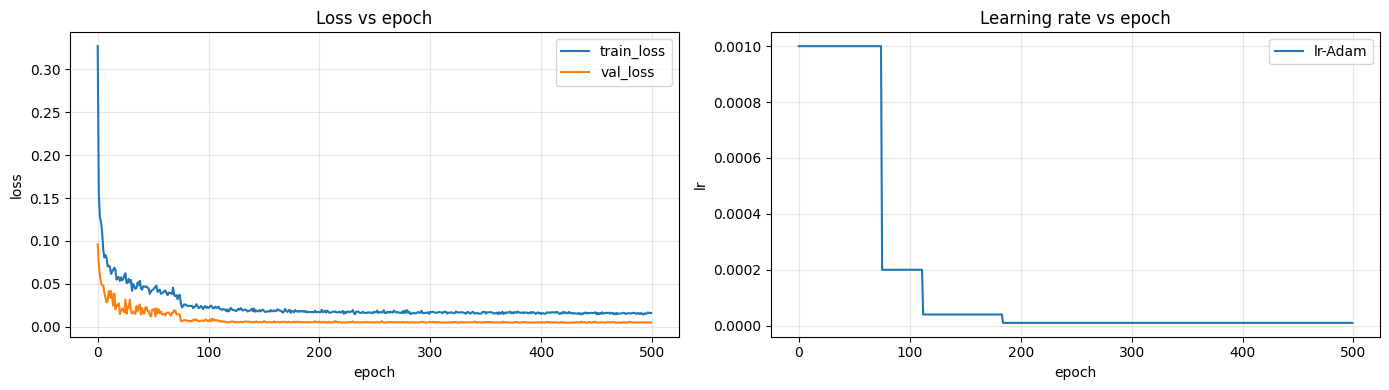

In [5]:
display(run.history().tail(8))
run.plot_history()

## 5) Best &amp; final epoch

In [6]:
run.best_epoch()

{'best_epoch': 445,
 'best_val_loss': 0.0044425195083022,
 'final_epoch': 499,
 'final_train_loss': 0.0159837491810321,
 'final_val_loss': 0.004876950290054}

In [7]:
RunLoader.compare_versions(LOG_ROOT)

""


## 6) Compare multiple Lightning versions

,run,best_val_loss,best_epoch
0,run_1,0.004169,438
1,run_2,0.004006,474
2,run_3,0.004443,445


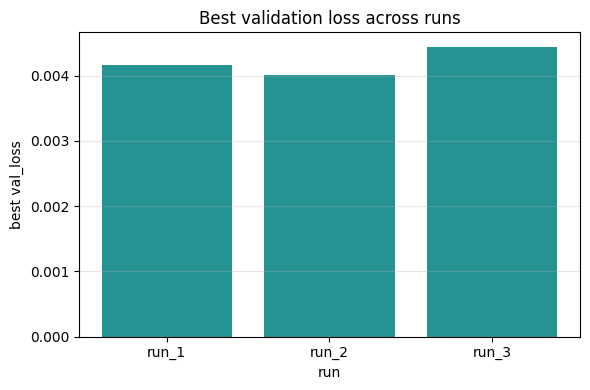

In [8]:
import pandas as pd

# Scan for all run_* directories and compare them
run_dirs = sorted([p for p in LOG_ROOT.glob('run_*') if p.is_dir()])
rows = []
for run_dir in run_dirs:
    csv_path = run_dir / 'metrics.csv'
    if not csv_path.exists():
        continue
    df = pd.read_csv(csv_path)
    valid = df.dropna(subset=['val_loss'])
    if not valid.empty:
        best_idx = valid['val_loss'].idxmin()
        rows.append({
            'run': run_dir.name,
            'best_val_loss': float(valid.loc[best_idx, 'val_loss']),
            'best_epoch': int(valid.loc[best_idx, 'epoch']) if 'epoch' in valid.columns else None,
        })

compare_df = pd.DataFrame(rows) if rows else pd.DataFrame()
display(compare_df)

if compare_df.empty:
    print(f"No runs found with metrics.csv in {LOG_ROOT}")
else:
    plt.figure(figsize=(6, 4))
    plt.bar(compare_df['run'], compare_df['best_val_loss'], color='teal', alpha=0.85)
    plt.title('Best validation loss across runs')
    plt.xlabel('run'); plt.ylabel('best val_loss')
    plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

## 7) Per-channel regression metrics

,channel_index,channel,mse,rmse,mae,r2,pearson_r,mean_abs_ground_truth,nrmse
2,2,Pzz_e,0.001195,0.034568,0.025453,0.998805,0.999450,0.855697,0.040397
1,1,Pyy_e,0.001479,0.038453,0.028508,0.998521,0.999340,0.855330,0.044957
0,0,Pxx_e,0.001881,0.043372,0.030321,0.998119,0.999087,0.853565,0.050813
4,4,Pxz_e,0.004536,0.067351,0.045154,0.995464,0.997820,0.577761,0.116572
5,5,Pyz_e,0.005098,0.071403,0.048569,0.994902,0.997465,0.329227,0.216882
3,3,Pxy_e,0.012470,0.111670,0.077770,0.987530,0.993799,0.466570,0.239341


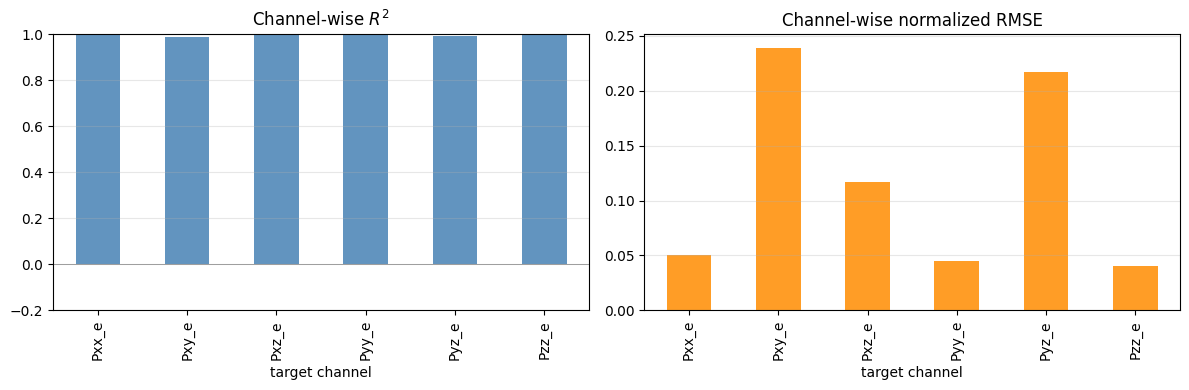

In [9]:
metrics_df = run.metrics()
display(metrics_df.sort_values('r2', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ms = metrics_df.set_index('channel').sort_index()

ms['r2'].plot.bar(ax=axes[0], color='steelblue', alpha=0.85)
axes[0].set_title('Channel-wise $R^2$')
axes[0].set_ylim(-0.2, 1.0)
axes[0].axhline(0, color='grey', linewidth=0.5)
axes[0].grid(axis='y', alpha=0.3)

ms['nrmse'].plot.bar(ax=axes[1], color='darkorange', alpha=0.85)
axes[1].set_title('Channel-wise normalized RMSE')
axes[1].grid(axis='y', alpha=0.3)

for ax in axes:
    ax.set_xlabel('target channel')
plt.tight_layout(); plt.show()

## 8) Predicted vs ground-truth images

Diagonal pressures (e.g. $P_{xx}$) use a sequential colormap.
Off-diagonal pressures ($P_{xy}$, etc.) are signed → diverging colormap.

invfunc = <ufunc 'exp'>


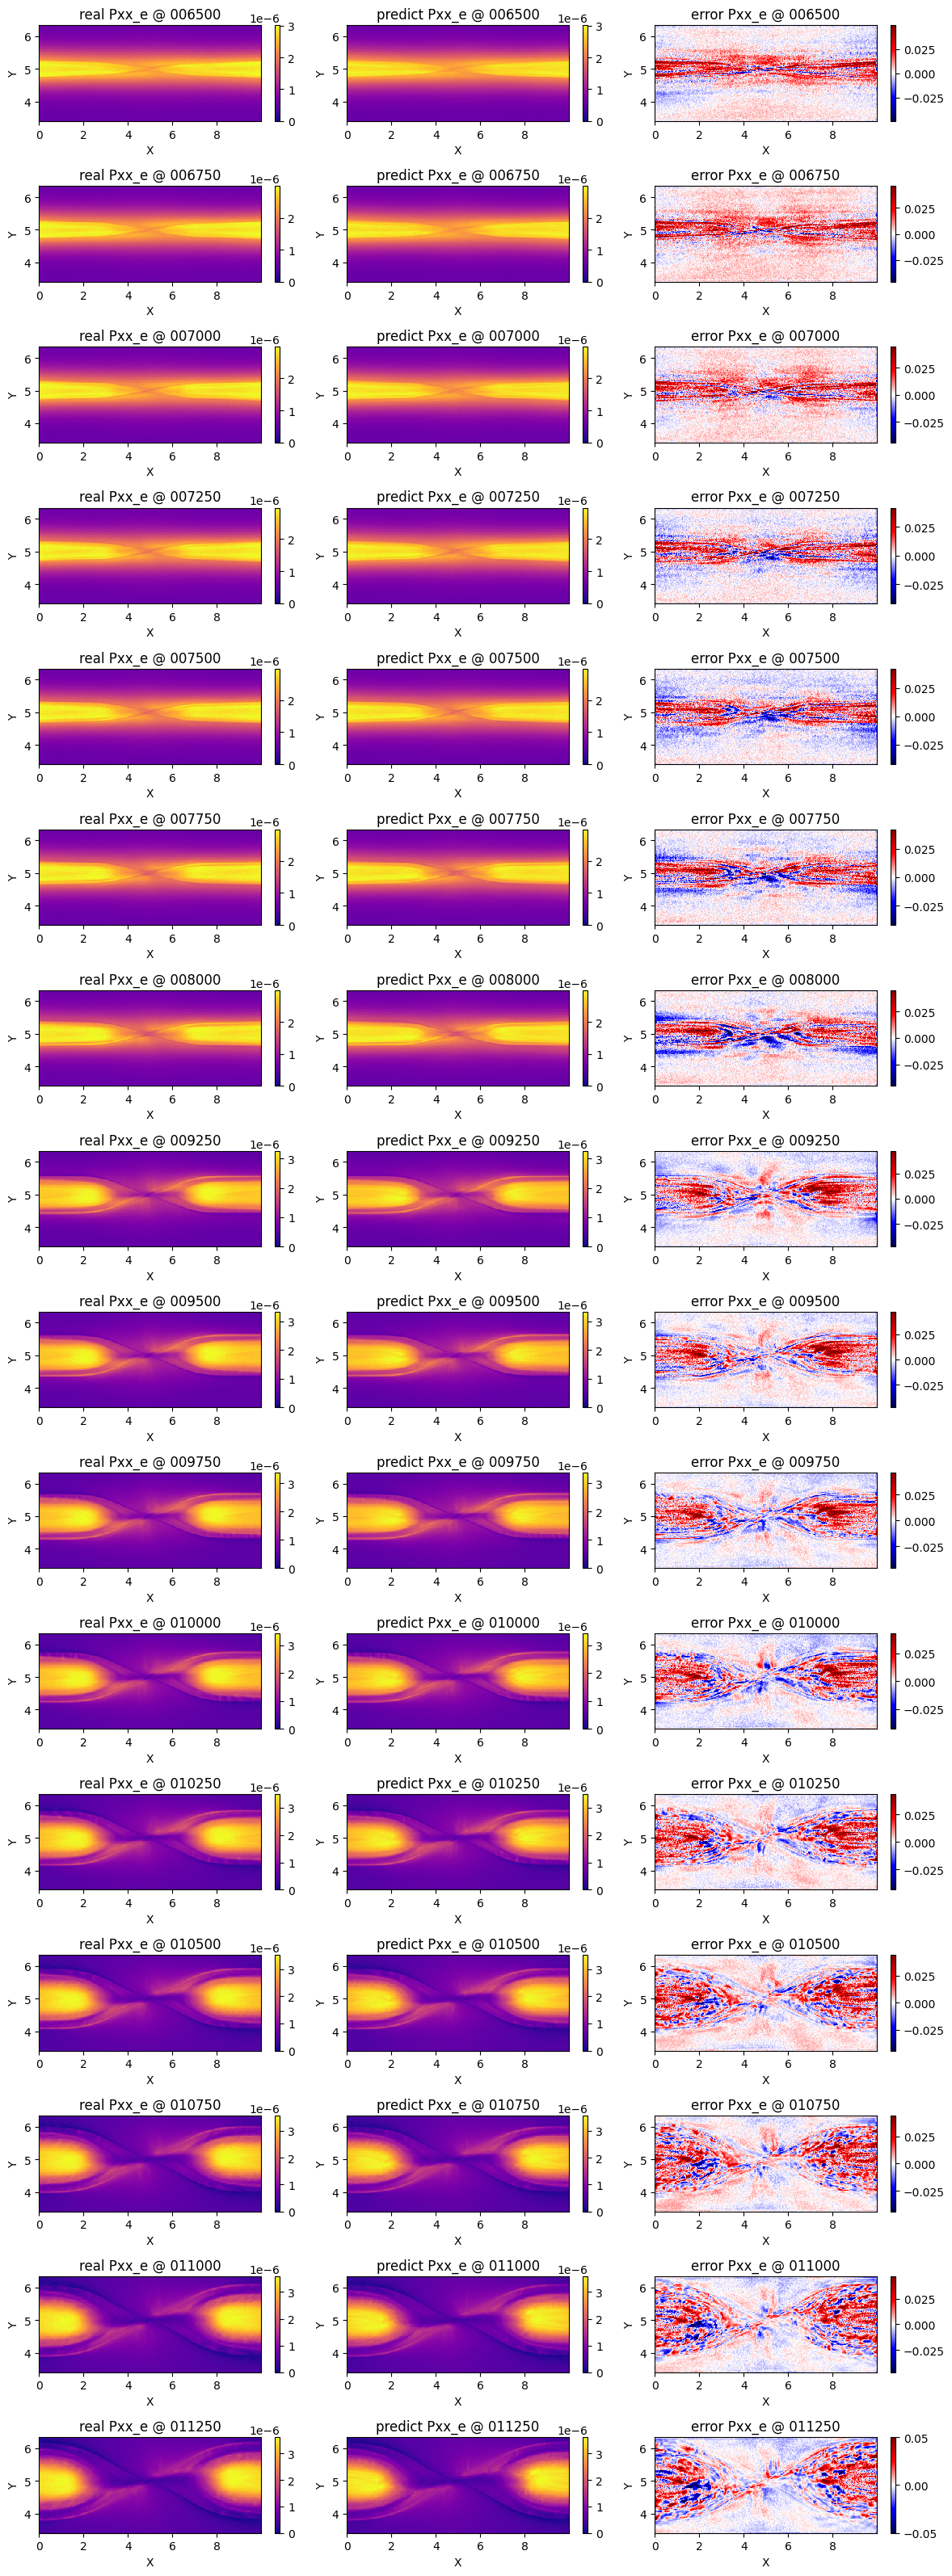

In [10]:
# Diagonal pressure
run.plot('Pxx_e', robust_quantile=0.995, error_mode='relative',
         signed_target_names=['Pxy_e', 'Pxz_e', 'Pyz_e'])

invfunc = <ufunc 'sinh'>


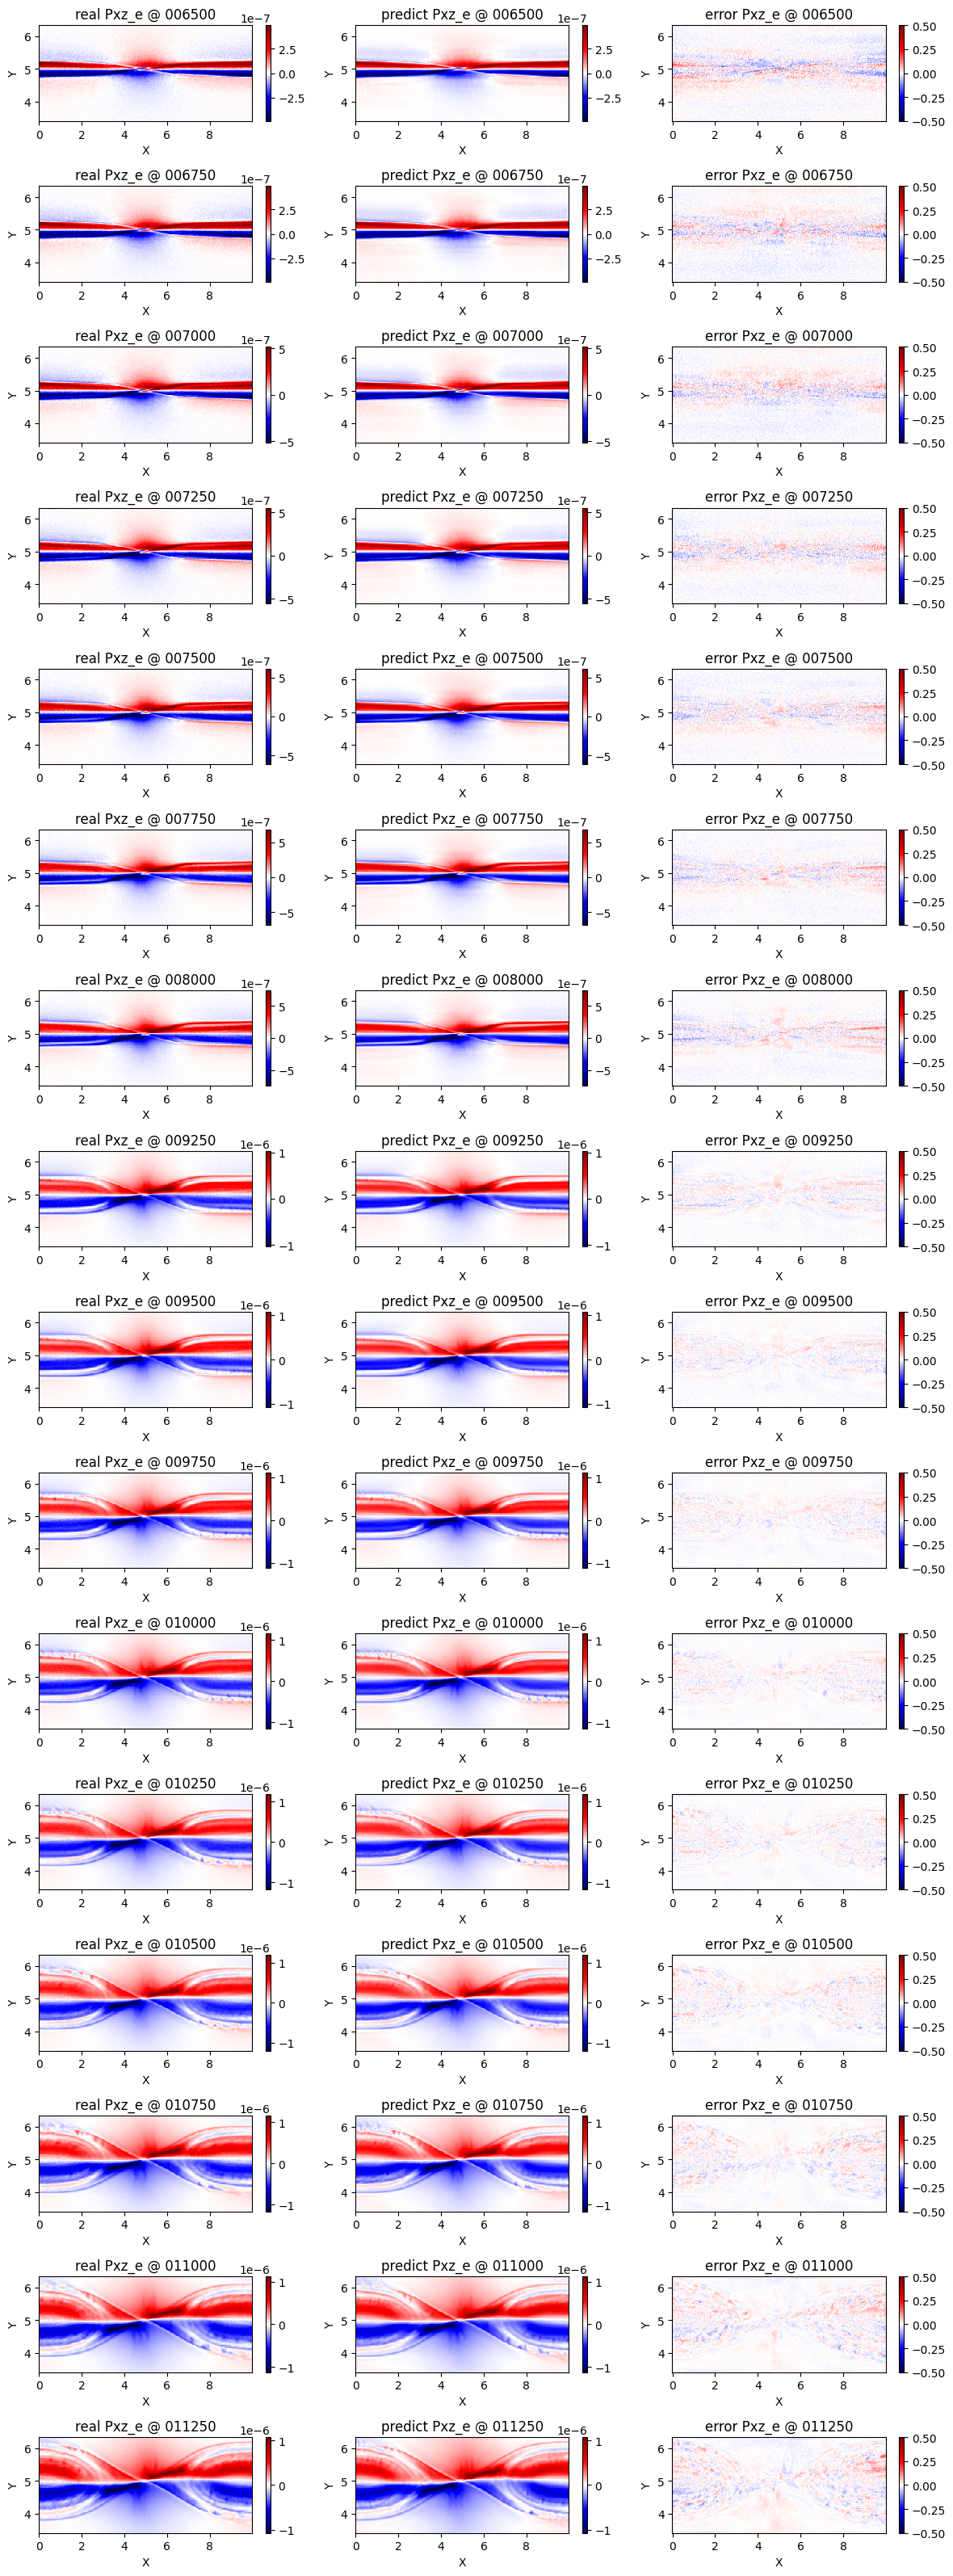

In [11]:
# Off-diagonal pressure (signed → diverging colormap)
offdiag = 'Pxz_e' if 'Pxz_e' in run.dataset.request_targets else run.dataset.request_targets[0]
run.plot(offdiag, robust_quantile=0.995, error_mode='symmetric_percent',
         error_limit=0.5, signed_target_names=['Pxy_e', 'Pxz_e', 'Pyz_e'])

Plotting off-diagonal channel: Pxy_e
invfunc = <ufunc 'sinh'>


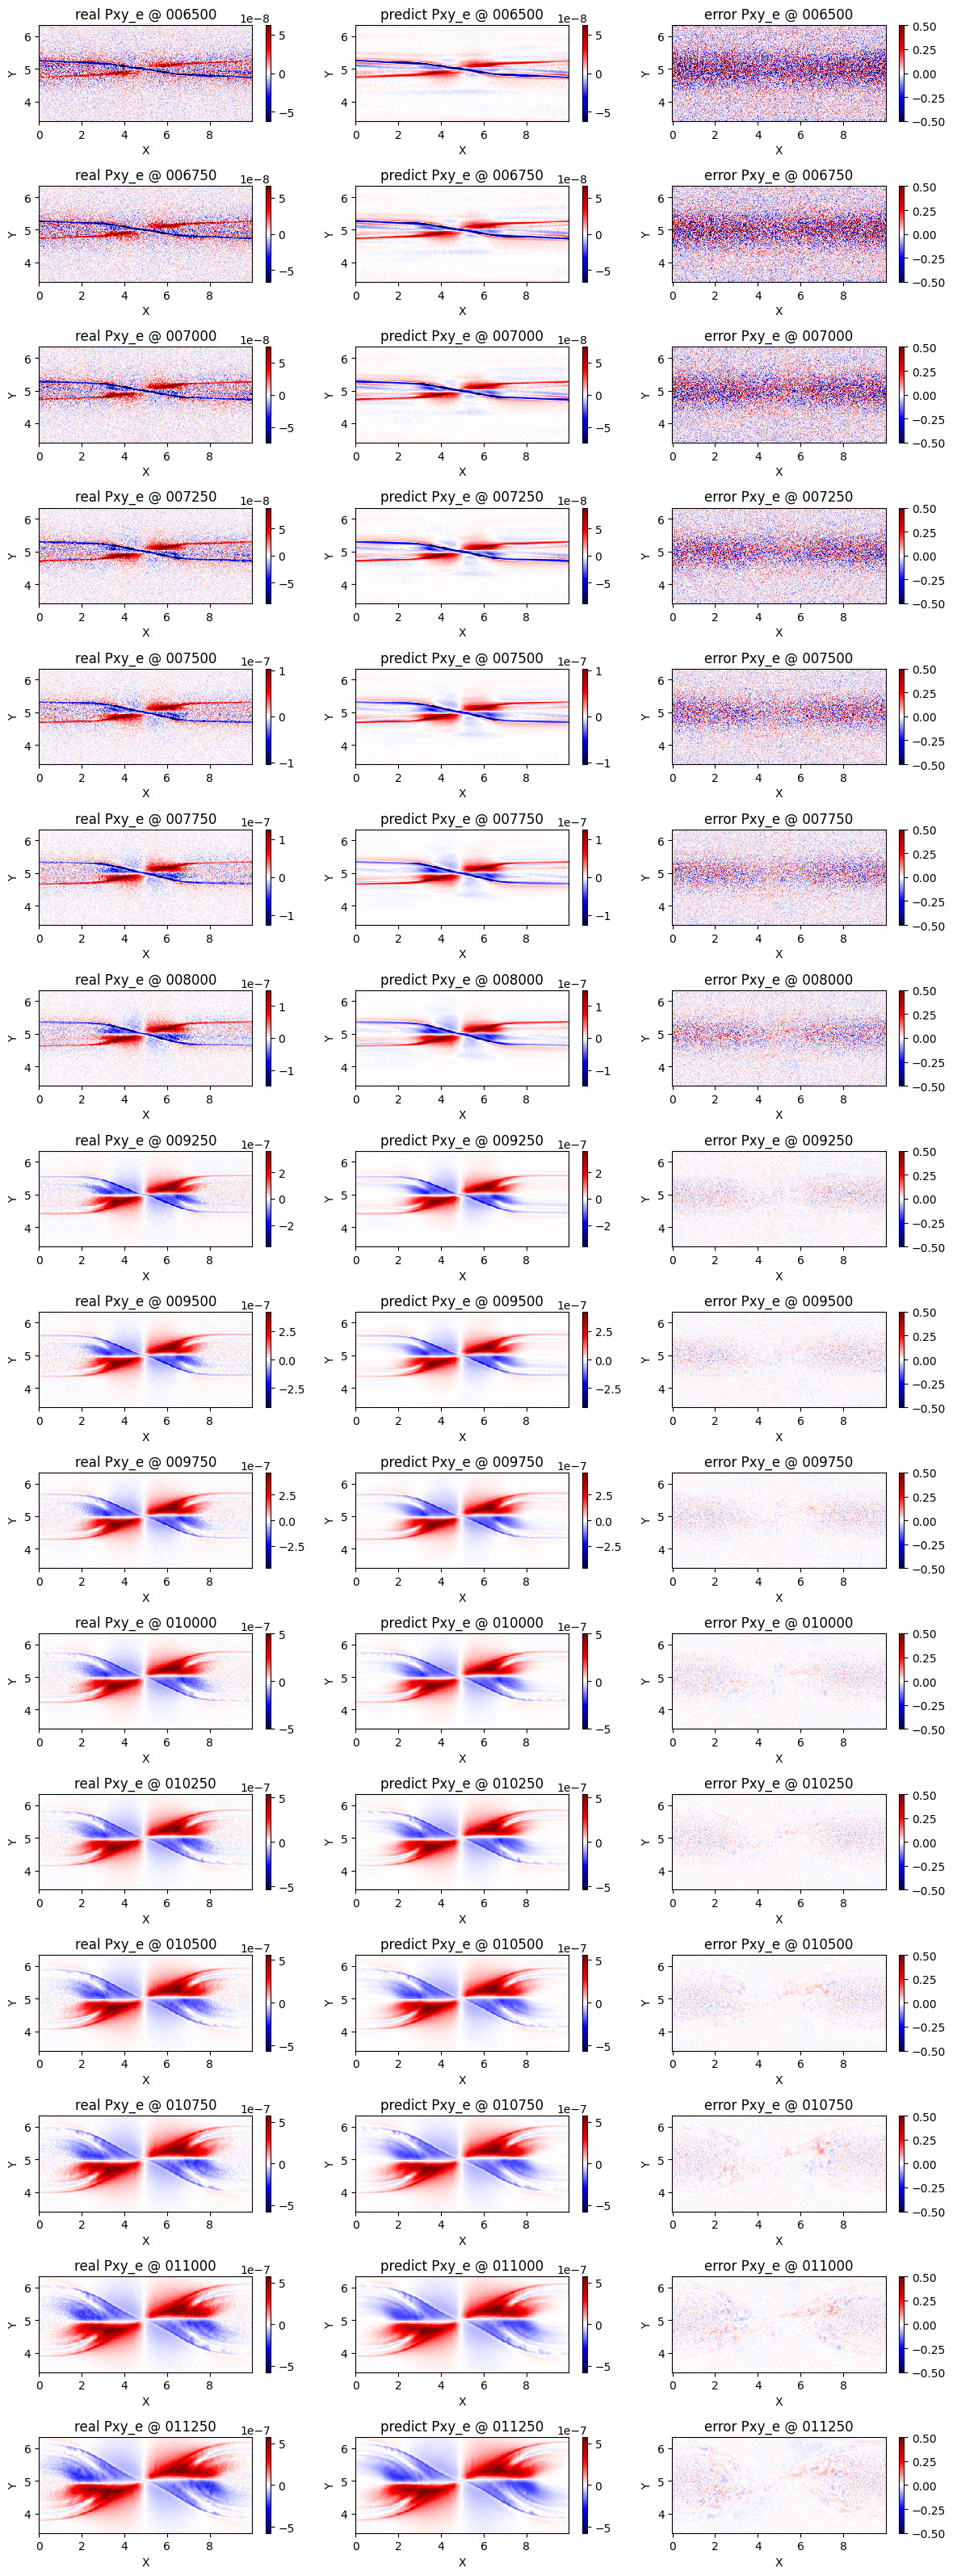

In [12]:
# Off-diagonal pressure (signed → diverging colormap)
offdiag = 'Pxy_e' if 'Pxy_e' in run.dataset.request_targets else run.dataset.request_targets[0]
print(f"Plotting off-diagonal channel: {offdiag}")
run.plot(offdiag, robust_quantile=0.995, error_mode='symmetric_percent',
         error_limit=0.5, signed_target_names=['Pxy_e', 'Pxz_e', 'Pyz_e'])

## 9) Predicted vs true scatter

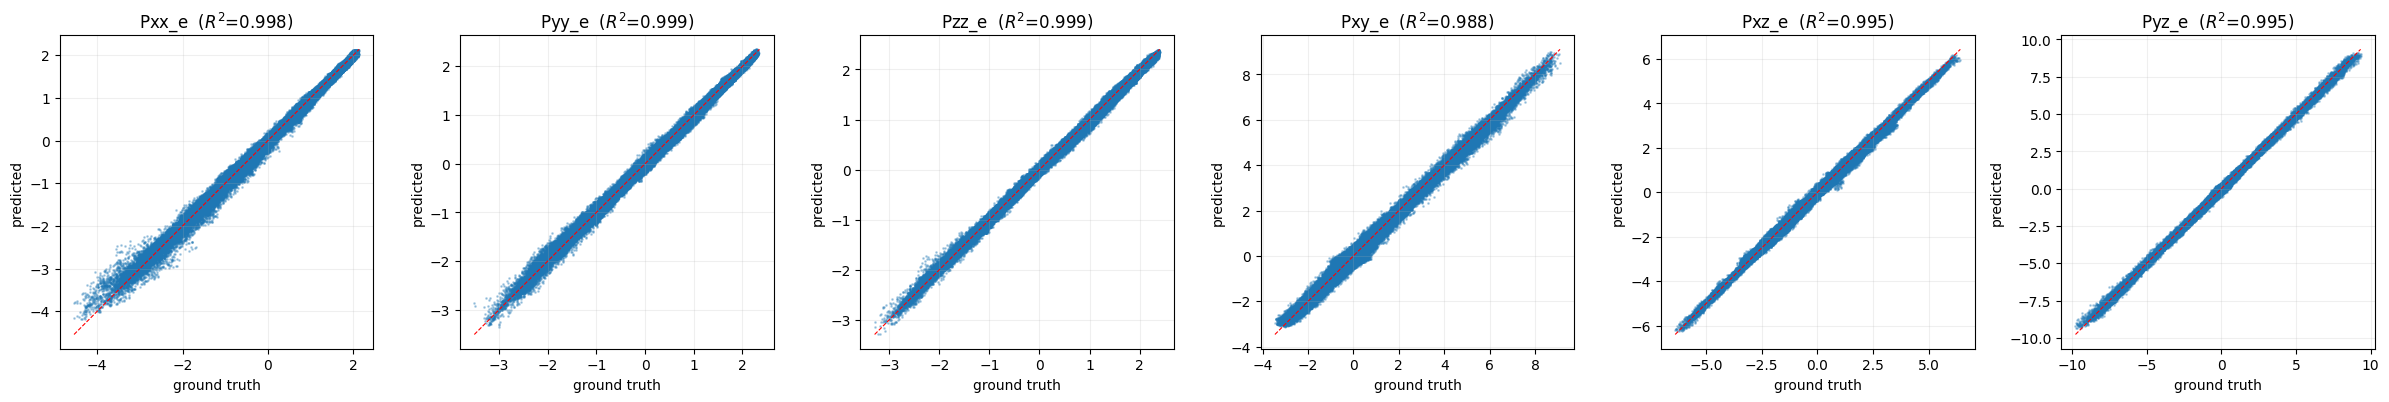

In [13]:
gt, pred = run.predict()
channels = run.dataset.request_targets
n_ch = len(channels)

fig, axes = plt.subplots(1, n_ch, figsize=(4 * n_ch, 4), squeeze=False)
for idx, ch_name in enumerate(channels):
    ax = axes[0, idx]
    y, yhat = gt[:, idx].ravel(), pred[:, idx].ravel()
    ax.scatter(y, yhat, s=1, alpha=0.3)
    lims = [min(y.min(), yhat.min()), max(y.max(), yhat.max())]
    ax.plot(lims, lims, 'r--', linewidth=0.8)
    ax.set_xlabel('ground truth'); ax.set_ylabel('predicted')
    r2 = metrics_df.loc[metrics_df.channel == ch_name, 'r2'].values[0]
    ax.set_title(f'{ch_name}  ($R^2$={r2:.3f})')
    ax.set_aspect('equal', adjustable='box'); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()